In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt                 

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\eda_project\data\cleaning2")

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0


## 1. Univariate Analysis

Text(0, 0.5, 'Count')

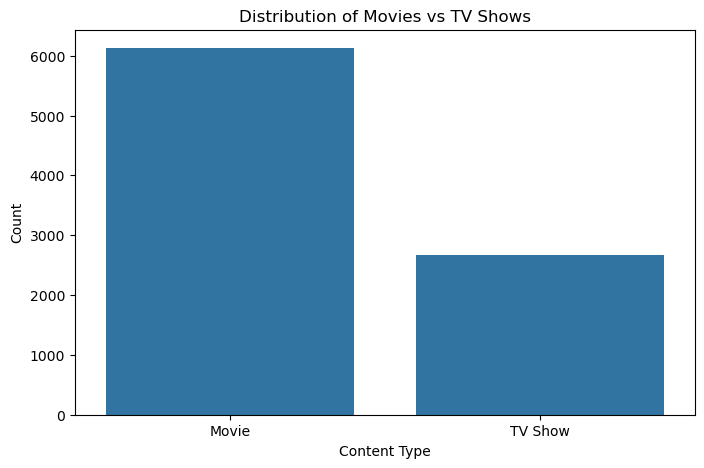

In [2]:
#Movies vs TV Shows
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")


- Movies are more frequent than TV Shows on Netflix.
- Movies constitute a significantly larger portion of Netflix content compared to TV Shows.
- The platform appears to focus more on movie content than series-based content.
- The imbalance suggests that Netflix’s catalog is dominated by standalone content rather than episodic content.



Text(0.5, 1.0, 'Ratings Distribution')

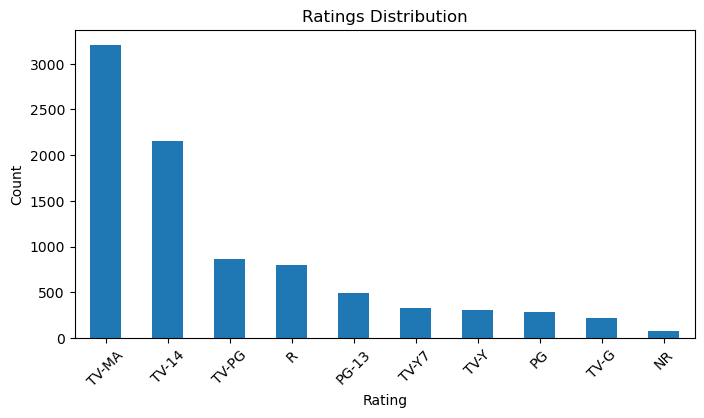

In [3]:
#Ratings Distribution
plt.figure(figsize=(8,4))
df['rating'].value_counts().head(10).plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Ratings Distribution")


- TV-MA and TV-14 are the most common ratings, indicating a focus on mature and teenage audiences.
- Family-friendly ratings such as PG and TV-G are comparatively less frequent.
- The distribution shows that Netflix content is skewed toward higher maturity levels.

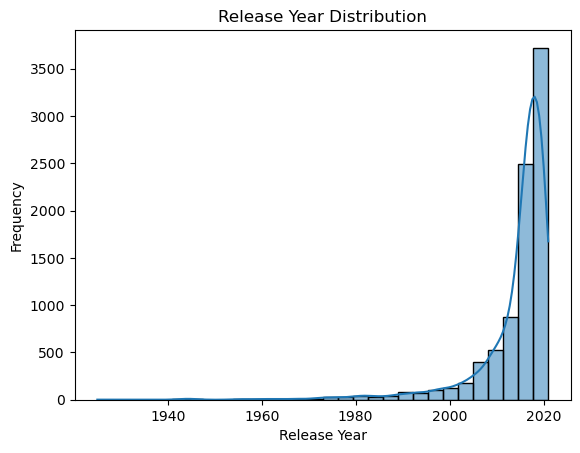

In [4]:
#Release Year Distribution
sns.histplot(df['release_year'], bins=30, kde=True)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()


- Most content has been released after 2000, with a strong concentration in recent years.
- There is a noticeable increase in content production after 2000.
- Older content (before 1980) forms a very small portion of the dataset.

## 2. Bivariate Analysis

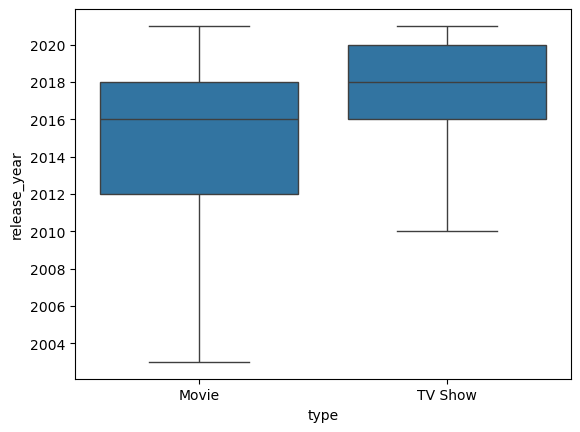

In [5]:
#Type vs Release Year
from matplotlib.ticker import MaxNLocator
ax = sns.boxplot(x='type', y='release_year', data=df, showfliers=False)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


- Movies are generally older, while TV shows are more recent.
- TV Shows tend to have a higher median release year, indicating more recent content.
- Movies show a wider spread in release years, including both older and newer titles.
- TV Shows are more concentrated in recent years, while Movies have a broader distribution.



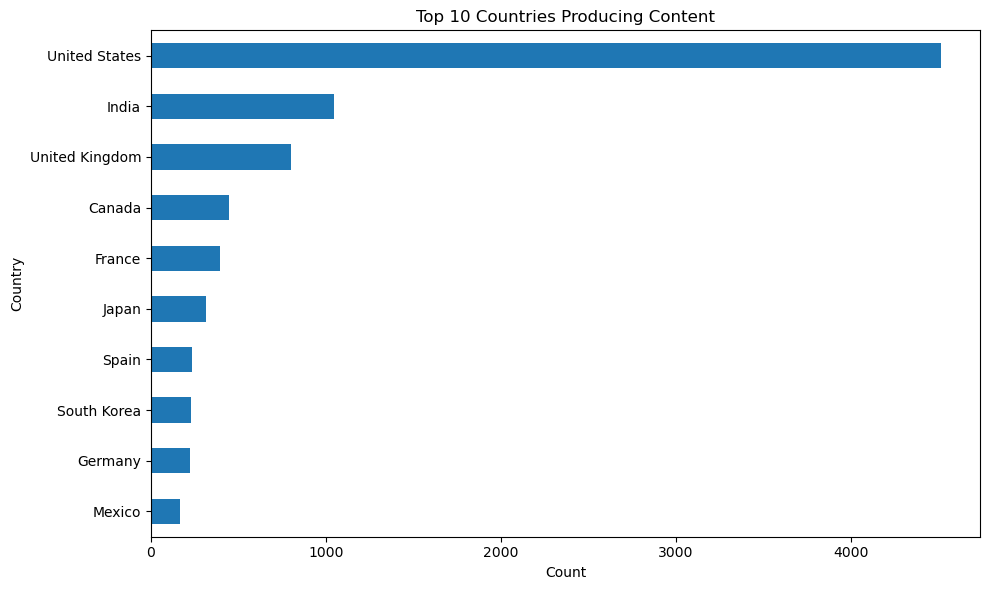

In [6]:
country_df = df.copy()
country_df['country'] = country_df['country'].str.split(', ')
country_df = country_df.explode('country')
top_country = country_df['country'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_country.sort_values().plot(kind='barh')
plt.xlabel("Count")
plt.ylabel("Country")
plt.title("Top 10 Countries Producing Content")
plt.tight_layout()
plt.show()


- The United States contributes the highest number of titles.
- A limited number of countries dominate the content production.
- There is representation from multiple countries, indicating global content diversity.

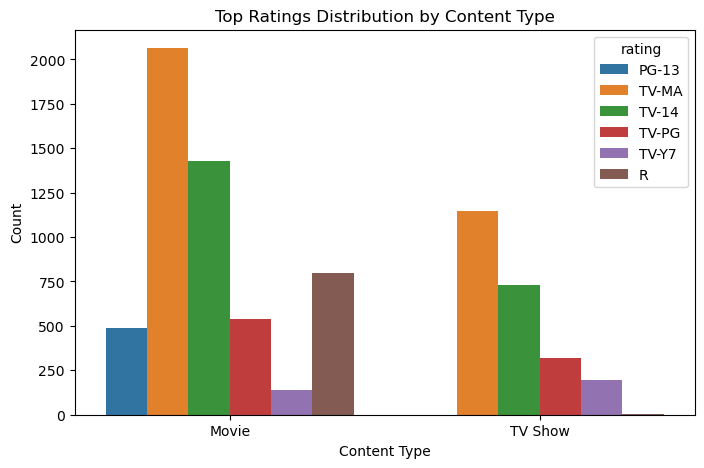

In [9]:
top = df['rating'].value_counts().nlargest(6).index
plt.figure(figsize=(8,5))
sns.countplot(
    data=df[df['rating'].isin(top)],
    x='type',
    hue='rating'
)
plt.title("Top Ratings Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

- TV-MA rating is common in both Movies and TV Shows.
- Movies have more rating variety.
- mostly target mature audiences.

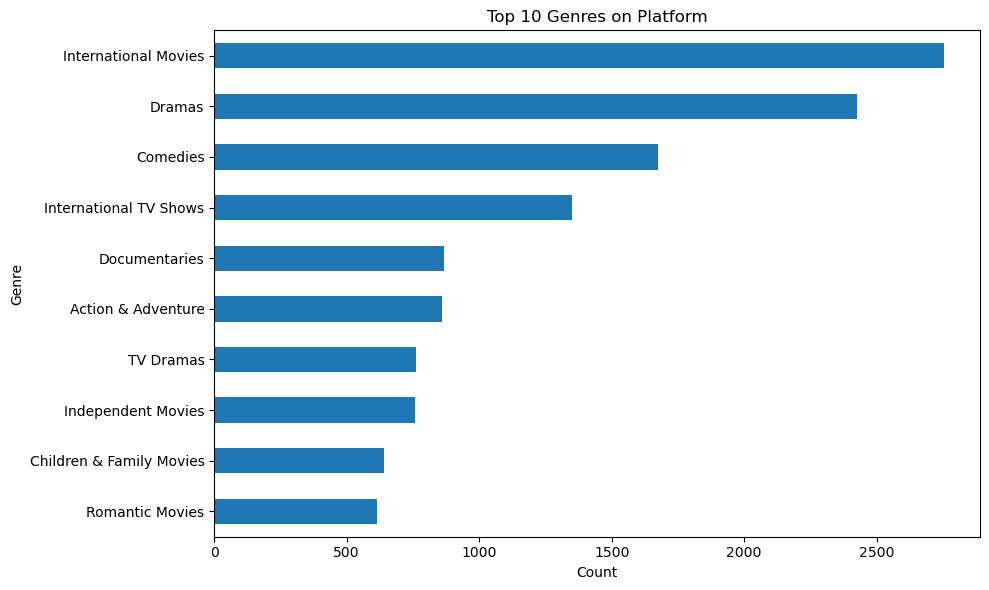

In [66]:
#Genre Analysis
genre_df = df.copy()
genre_df['listed_in'] = genre_df['listed_in'].str.split(', ')
genre_df = genre_df.explode('listed_in')
top_genres = genre_df['listed_in'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind='barh')
plt.xlabel("Count")
plt.ylabel("Genre")
plt.title("Top 10 Genres on Platform")
plt.tight_layout()
plt.show()

- International Movies is the most frequent genre, followed by drama and Comedy.
- A few genres dominate the distribution, while others appear less frequently.


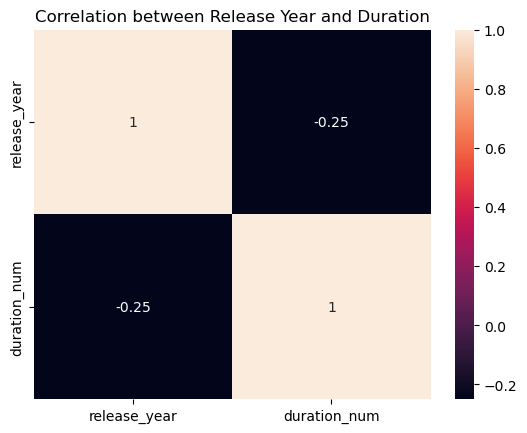

In [67]:
#Correlation Heatmap
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
sns.heatmap(df[['release_year','duration_num']].corr(), annot=True)
plt.title("Correlation between Release Year and Duration")
plt.show()



- Correlation analysis was limited due to fewer numerical features. Weak correlation was observed between release_year and duration.
- There is a weak negative correlation (-0.25) between release year and duration.
- This suggests that newer content tends to have slightly shorter durations.
- The relationship is weak, indicating that release year does not strongly affect duration.

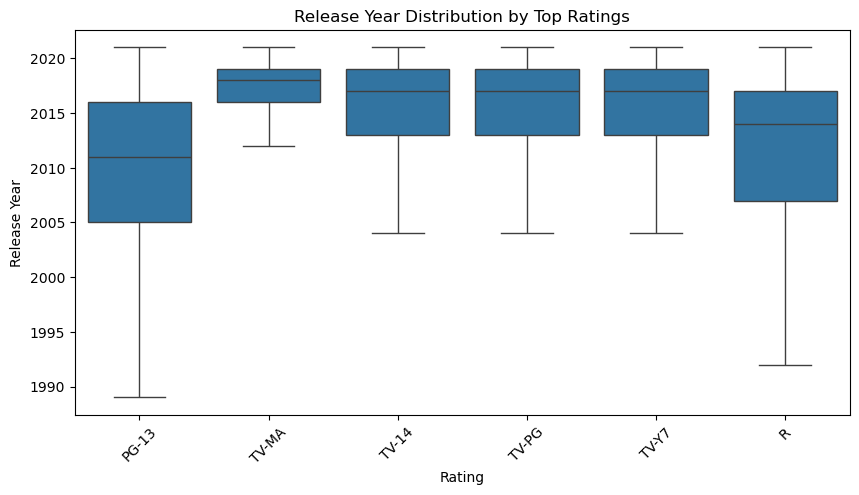

In [68]:
#3. Numeric vs Categorical
top_ratings = df['rating'].value_counts().head(6).index
plt.figure(figsize=(10,5))
sns.boxplot(data=df[df['rating'].isin(top_ratings)],
            x='rating', y='release_year',
            showfliers=False)
plt.xticks(rotation=45)
plt.title("Release Year Distribution by Top Ratings")
plt.xlabel("Rating")
plt.ylabel("Release Year")
plt.show()


- Higher maturity ratings like TV-MA and TV-14 are more concentrated in recent years.
- Most ratings are associated with relatively recent release years.
- The boxplots show that rating categories such as TV-14, TV-PG, and TV-Y7 have very similar distributions in release year, indicating consistent temporal patterns.
-   TV-MA exhibits slight variation but largely follows the same trend. In contrast, ratings such as PG-13 and R display greater variability, including older content and a wider range of release years.”


## Univariate Analysis

- Movies dominate the dataset compared to TV Shows
- Most content is rated TV-MA and TV-14
- Majority of content is produced after 2000


## Bivariate Analysis

- USA produces the highest number of Netflix titles
- Drama and International genres are most common
- TV Shows are generally more recent than Movies
- TV-MA rating is common in both Movies and TV Shows.
-  Movies have more rating variety.
  


In [69]:
df.to_csv(r"C:\Users\HP\OneDrive\Desktop\eda_project\notebook\visualisation3", index=False)
